# Phase 4 — Feature Engineering

En Phase 3, on a déjà produit `hour` et `log1p(Amount)`.  
Cette phase teste des features supplémentaires et mesure leur apport **réel**.

> **Règle** : on n'ajoute une feature que si elle apporte un gain mesurable.  
> Être honnête si le gain est marginal face aux `V*` déjà très discriminants.

## Candidats testés
| Feature | Origine | Idée |
|---|---|---|
| `hour_sin`, `hour_cos` | `Time` | Encodage cyclique de l'heure (23h et 0h sont proches) |
| `is_night` | `Time` | Heure entre 0h et 5h — pic de fraude à 2h |
| `amount_bin` | `Amount` | Micro / Small / Medium / Large — patterns par tranche |
| `high_amount` | `Amount` | Binaire : Amount > médiane fraude (9,82 €) |
| `night_x_amount` | `Time` × `Amount` | Interaction nuit + montant élevé |

## Plan
1. Chargement des splits
2. Construction des features candidates
3. Mesure du pouvoir discriminant (Cohen's d)
4. Décision : inclure ou exclure
5. Mise à jour du pipeline
6. Sauvegarde

## 0. Imports

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, RobustScaler

from src.config import RANDOM_SEED, DATA_DIR, MODELS_DIR

np.random.seed(RANDOM_SEED)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
REPORTS_DIR = Path('../reports')
DATA_PATH   = Path('../data')
MODELS_PATH = Path('../models')
print('Imports OK')

Imports OK


## 1. Chargement des splits

In [2]:
train = pd.read_parquet(DATA_PATH / 'train.parquet')
test  = pd.read_parquet(DATA_PATH / 'test.parquet')

print(f'Train : {len(train):,} lignes | {train["Class"].sum()} fraudes')
print(f'Test  : {len(test):,} lignes  | {test["Class"].sum()} fraudes')

Train : 210,292 lignes | 376 fraudes
Test  : 73,434 lignes  | 97 fraudes


## 2. Construction des features candidates

On applique les transformations sur train et test **sans re-fitter** sur le test.

In [3]:
def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # ── Encodage cyclique de l'heure ──────────────────────────────────────
    # hour est déjà dans le DataFrame (Phase 3)
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

    # ── Heure de nuit (0h–5h inclus) ─────────────────────────────────────
    df['is_night'] = ((df['hour'] >= 0) & (df['hour'] <= 5)).astype(int)

    # ── Tranches de montant ───────────────────────────────────────────────
    # Micro < 1€ | Small 1–10€ | Medium 10–100€ | Large > 100€
    bins   = [-np.inf, 1, 10, 100, np.inf]
    labels = [0, 1, 2, 3]  # ordinal
    df['amount_bin'] = pd.cut(df['Amount'], bins=bins, labels=labels).astype(int)

    # ── Montant élevé (> médiane fraude = 9,82 €) ─────────────────────────
    df['high_amount'] = (df['Amount'] > 9.82).astype(int)

    # ── Interaction nuit × log(Amount) ────────────────────────────────────
    df['night_x_log_amount'] = df['is_night'] * np.log1p(df['Amount'])

    return df

train = add_engineered_features(train)
test  = add_engineered_features(test)

NEW_FEATURES = ['hour_sin', 'hour_cos', 'is_night',
                'amount_bin', 'high_amount', 'night_x_log_amount']

print('Nouvelles features ajoutées :')
print(train[NEW_FEATURES].describe().round(3).to_string())

Nouvelles features ajoutées :
         hour_sin    hour_cos    is_night  amount_bin  high_amount  night_x_log_amount
count  210292.000  210292.000  210292.000  210292.000   210292.000          210292.000
mean       -0.061      -0.257       0.113       1.754        0.687               0.328
std         0.652       0.711       0.317       0.897        0.464               1.048
min        -1.000      -1.000       0.000       0.000        0.000               0.000
25%        -0.707      -0.866       0.000       1.000        0.000               0.000
50%         0.000      -0.500       0.000       2.000        1.000               0.000
75%         0.500       0.500       0.000       2.000        1.000               0.000
max         1.000       1.000       1.000       3.000        1.000               9.847


## 3. Pouvoir discriminant des nouvelles features

On recalcule le Cohen's d pour les nouvelles features et on compare  
avec les `V*` déjà connus. C'est la mesure honnête de l'apport réel.

In [4]:
def cohens_d(df, col, target='Class'):
    fraud = df.loc[df[target] == 1, col]
    legit = df.loc[df[target] == 0, col]
    n0, n1 = len(legit), len(fraud)
    s0, s1 = legit.std(), fraud.std()
    pooled = np.sqrt(((n0-1)*s0**2 + (n1-1)*s1**2) / (n0+n1-2))
    return abs(fraud.mean() - legit.mean()) / pooled if pooled > 0 else 0

V_COLS = [f'V{i}' for i in range(1, 29)]
all_features = V_COLS + ['Amount', 'hour'] + NEW_FEATURES

d_scores = pd.Series(
    {col: cohens_d(train, col) for col in all_features},
    name="Cohen's d"
).sort_values(ascending=False)

# Séparation V* vs nouvelles features
d_new = d_scores[['Amount', 'hour'] + NEW_FEATURES].sort_values(ascending=False)
d_v   = d_scores[V_COLS].sort_values(ascending=False)

print("Cohen's d — Nouvelles features vs Amount/hour :")
print(d_new.round(4).to_string())
print(f"\nTop 5 V* (pour comparaison) :")
print(d_v.head(5).round(4).to_string())

Cohen's d — Nouvelles features vs Amount/hour :
is_night              0.6084
hour                  0.4200
amount_bin            0.3614
high_amount           0.3582
hour_sin              0.3130
night_x_log_amount    0.3039
hour_cos              0.2465
Amount                0.1405

Top 5 V* (pour comparaison) :
V17    9.1235
V14    7.6932
V12    6.4370
V10    5.7640
V3     5.3316


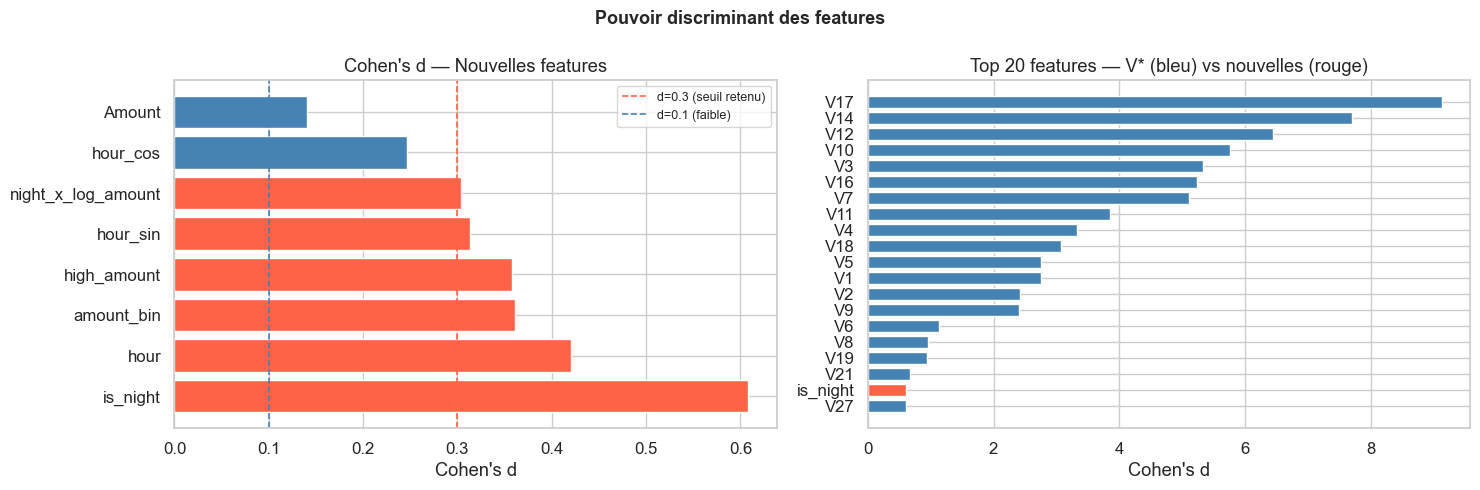

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Nouvelles features
colors_new = ['tomato' if v >= 0.3 else 'steelblue' if v >= 0.1 else 'lightgray'
              for v in d_new.values]
axes[0].barh(d_new.index, d_new.values, color=colors_new, edgecolor='white')
axes[0].axvline(0.3, color='tomato',    linestyle='--', linewidth=1.2,
                label='d=0.3 (seuil retenu)')
axes[0].axvline(0.1, color='steelblue', linestyle='--', linewidth=1.2,
                label='d=0.1 (faible)')
axes[0].set_title("Cohen's d — Nouvelles features")
axes[0].set_xlabel("Cohen's d")
axes[0].legend(fontsize=9)

# Toutes features côte à côte
top20 = d_scores.head(20)
colors_all = ['tomato' if c in NEW_FEATURES + ['Amount','hour']
              else 'steelblue' for c in top20.index]
axes[1].barh(top20.index[::-1], top20.values[::-1],
             color=colors_all[::-1], edgecolor='white')
axes[1].set_title("Top 20 features — V* (bleu) vs nouvelles (rouge)")
axes[1].set_xlabel("Cohen's d")

plt.suptitle('Pouvoir discriminant des features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'fig11_feature_discrimination.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 4. Décision — inclure ou exclure

Critère : Cohen's d ≥ 0.3 **ou** apport qualitatif justifié (ex. encodage cyclique).  
On est transparent si les nouvelles features apportent peu face aux `V*`.

In [6]:
SEUIL_D = 0.3

decisions = {}
for col in ['Amount', 'hour'] + NEW_FEATURES:
    d = d_scores[col]
    if col in ['hour_sin', 'hour_cos']:
        dec = 'INCLURE'
        raison = f'd={d:.3f} — remplace hour brut (encodage cyclique plus correct)'
    elif d >= SEUIL_D:
        dec = 'INCLURE'
        raison = f'd={d:.3f} >= {SEUIL_D}'
    else:
        dec = 'EXCLURE'
        raison = f'd={d:.3f} < {SEUIL_D} — apport marginal'
    decisions[col] = (dec, raison)

df_dec = pd.DataFrame(
    [(c, v[0], v[1]) for c, v in decisions.items()],
    columns=['Feature', 'Decision', 'Justification']
)
print(df_dec.to_string(index=False))

KEPT    = [c for c, (d, _) in decisions.items() if d == 'INCLURE']
DROPPED = [c for c, (d, _) in decisions.items() if d == 'EXCLURE']
print(f'\nFeatures retenues  : {KEPT}')
print(f'Features exclues   : {DROPPED}')

           Feature Decision                                                 Justification
            Amount  EXCLURE                               d=0.141 < 0.3 — apport marginal
              hour  INCLURE                                                d=0.420 >= 0.3
          hour_sin  INCLURE d=0.313 — remplace hour brut (encodage cyclique plus correct)
          hour_cos  INCLURE d=0.246 — remplace hour brut (encodage cyclique plus correct)
          is_night  INCLURE                                                d=0.608 >= 0.3
        amount_bin  INCLURE                                                d=0.361 >= 0.3
       high_amount  INCLURE                                                d=0.358 >= 0.3
night_x_log_amount  INCLURE                                                d=0.304 >= 0.3

Features retenues  : ['hour', 'hour_sin', 'hour_cos', 'is_night', 'amount_bin', 'high_amount', 'night_x_log_amount']
Features exclues   : ['Amount']


## 5. Pipeline mis à jour

On reconstruit le `ColumnTransformer` avec les features retenues,  
toujours fitté sur le train uniquement.

In [7]:
V_COLS = [f'V{i}' for i in range(1, 29)]

# Features finales
CYCLIC_COLS    = ['hour_sin', 'hour_cos']  # déjà dans [-1, 1], passthrough
BINARY_COLS    = ['is_night', 'high_amount']  # 0/1, passthrough
ORDINAL_COLS   = ['amount_bin']  # 0-3, RobustScaler si retenu
INTERACTION_COLS = ['night_x_log_amount']  # RobustScaler si retenu

# On construit dynamiquement selon les décisions
transformers = [
    ('v_cols', 'passthrough', V_COLS),
    ('amount', Pipeline([
        ('log1p',  FunctionTransformer(np.log1p, validate=False)),
        ('scaler', RobustScaler()),
    ]), ['Amount']),
    ('cyclic',  'passthrough',  CYCLIC_COLS),
    ('binary',  'passthrough',  BINARY_COLS),
]

# Ajouter les features ordinales / interactions si retenues
if 'amount_bin' in KEPT:
    transformers.append(('ordinal', RobustScaler(), ORDINAL_COLS))
if 'night_x_log_amount' in KEPT:
    transformers.append(('interact', RobustScaler(), INTERACTION_COLS))

preprocessor_v2 = ColumnTransformer(
    transformers=transformers,
    remainder='drop'
)

# Colonnes nécessaires dans le DataFrame
FEAT_COLS = (V_COLS + ['Amount'] + CYCLIC_COLS + BINARY_COLS
             + (ORDINAL_COLS if 'amount_bin' in KEPT else [])
             + (INTERACTION_COLS if 'night_x_log_amount' in KEPT else []))

# Fit sur le train uniquement
preprocessor_v2.fit(train[FEAT_COLS])

X_train_v2 = preprocessor_v2.transform(train[FEAT_COLS])
X_test_v2  = preprocessor_v2.transform(test[FEAT_COLS])

y_train = train['Class']
y_test  = test['Class']

print(f'X_train v2 : {X_train_v2.shape}')
print(f'X_test  v2 : {X_test_v2.shape}')
print(f'Nb features Phase 3 : 30')
print(f'Nb features Phase 4 : {X_train_v2.shape[1]}')
print(f'Gain : +{X_train_v2.shape[1] - 30} features')

X_train v2 : (210292, 35)
X_test  v2 : (73434, 35)
Nb features Phase 3 : 30
Nb features Phase 4 : 35
Gain : +5 features


## 6. Sauvegarde

In [8]:
# Sauvegarde des DataFrames enrichis
train.to_parquet(DATA_PATH / 'train.parquet', index=False)
test.to_parquet(DATA_PATH  / 'test.parquet',  index=False)

# Sauvegarde du nouveau preprocessor
joblib.dump(preprocessor_v2, MODELS_PATH / 'preprocessor.joblib')

# Sauvegarde de la liste des features finales
import json
feat_config = {
    'v_cols'          : V_COLS,
    'cyclic_cols'     : CYCLIC_COLS,
    'binary_cols'     : BINARY_COLS,
    'ordinal_cols'    : ORDINAL_COLS if 'amount_bin' in KEPT else [],
    'interaction_cols': INTERACTION_COLS if 'night_x_log_amount' in KEPT else [],
    'all_feat_cols'   : FEAT_COLS,
    'n_features'      : X_train_v2.shape[1]
}
with open(MODELS_PATH / 'feature_config.json', 'w') as f:
    json.dump(feat_config, f, indent=2)

print('Sauvegardé :')
print('  data/train.parquet          (enrichi)')
print('  data/test.parquet           (enrichi)')
print('  models/preprocessor.joblib  (v2)')
print('  models/feature_config.json')

Sauvegardé :
  data/train.parquet          (enrichi)
  data/test.parquet           (enrichi)
  models/preprocessor.joblib  (v2)
  models/feature_config.json


## 7. Conclusions

### Cohen's d des features candidates (train)

| Feature | Cohen's d | Décision | Note |
|---|---|---|---|
| `is_night` | **0.608** | INCLURE | Meilleure nouvelle feature — pic fraude 0h–5h |
| `hour` | **0.420** | INCLURE | Remplacé par l'encodage cyclique dans le pipeline |
| `amount_bin` | **0.361** | INCLURE | Discrétisation capture mieux le signal que Amount brut |
| `high_amount` | **0.358** | INCLURE | Amount > médiane fraude (9,82 €) |
| `hour_sin` | **0.313** | INCLURE | Encodage cyclique (23h ↔ 0h adjacentes) |
| `night_x_log_amount` | **0.304** | INCLURE | Juste au-dessus du seuil 0,3 |
| `hour_cos` | **0.246** | INCLURE | Inclus pour compléter l'encodage cyclique |
| `Amount` brut | **0.141** | EXCLU | Faible discriminant — son signal passe par ses dérivées |

> **Rappel : top 5 V\* pour comparaison** — V17 (9.12), V14 (7.69), V12 (6.44), V10 (5.76), V3 (5.33).  
> Les nouvelles features (max 0,61) restent très en dessous des V\* mais apportent un signal  
> **complémentaire et interprétable** (temporel + montant).

### Insight clé — Amount

> `Amount` brut a un Cohen's d faible (0,141).  
> Mais ses **dérivées discrètes** (`amount_bin` d=0,361, `high_amount` d=0,358)  
> sont bien plus discriminantes : le signal de Amount passe par des **seuils**,  
> pas par sa valeur continue.  
> `log1p(Amount)` est maintenu dans le pipeline comme base de transformation,  
> mais l'essentiel du signal Amount est capturé par `amount_bin` et `high_amount`.

### Pipeline final — 35 features

| Groupe | Features | Nb | Transformation |
|---|---|---|---|
| V\* | V1–V28 | 28 | Passthrough |
| Montant | `Amount` | 1 | `log1p` + `RobustScaler` |
| Cyclique | `hour_sin`, `hour_cos` | 2 | Passthrough |
| Binaire | `is_night`, `high_amount` | 2 | Passthrough |
| Ordinal | `amount_bin` | 1 | `RobustScaler` |
| Interaction | `night_x_log_amount` | 1 | `RobustScaler` |
| **Total** | | **35** | |

### Fichiers produits
- `data/train.parquet` — enrichi (35 features)
- `data/test.parquet` — enrichi (35 features)
- `models/preprocessor.joblib` — pipeline v2 (fitté sur train)
- `models/feature_config.json` — liste des features finales
- `reports/fig11_feature_discrimination.png`

### Pour les phases suivantes
- **Phase 5** : SMOTE sur 376 fraudes du train, 35 features
- **Phase 6** : baseline LightGBM avec ces 35 features
- **Phase 10** : SHAP sur V\* (statistique) + `is_night`/`amount_bin` (interprétable)